### Derived categorical variables



| Variable | Meaning | Source column | Categories |
|---|---|---|---|
| `nivel_actividad` | Activity level | `tx_count_m` (transactions per month) | No activity (0), Low (1-3), Medium (4-10), High (>10) |
| `perfil_oxxo` | OXXO profile | `oxxo_tx_ratio_m` (share of transactions at OXXO) | No OXXO (0), Mixed (0-0.5], Dependent (>0.5) |
| `perfil_digital` | Digital profile | `ecommerce_tx_ratio_m` (share of e-commerce transactions) | No e-commerce (0), Medium (0-0.5], High (>0.5) |

=== Categorías por variable categórica ===
nivel_actividad: {'Sin actividad': 137255, 'Baja (1-3)': 268369, 'Media (4-10)': 260739, 'Alta (>10)': 255075}
perfil_oxxo: {'Sin OXXO': 656019, 'Mixto (0-0.5]': 221035, 'Dependiente (>0.5)': 44384}
perfil_digital: {'Sin e-commerce': 329111, 'Medio (0-0.5]': 200750, 'Alto (>0.5)': 391577}


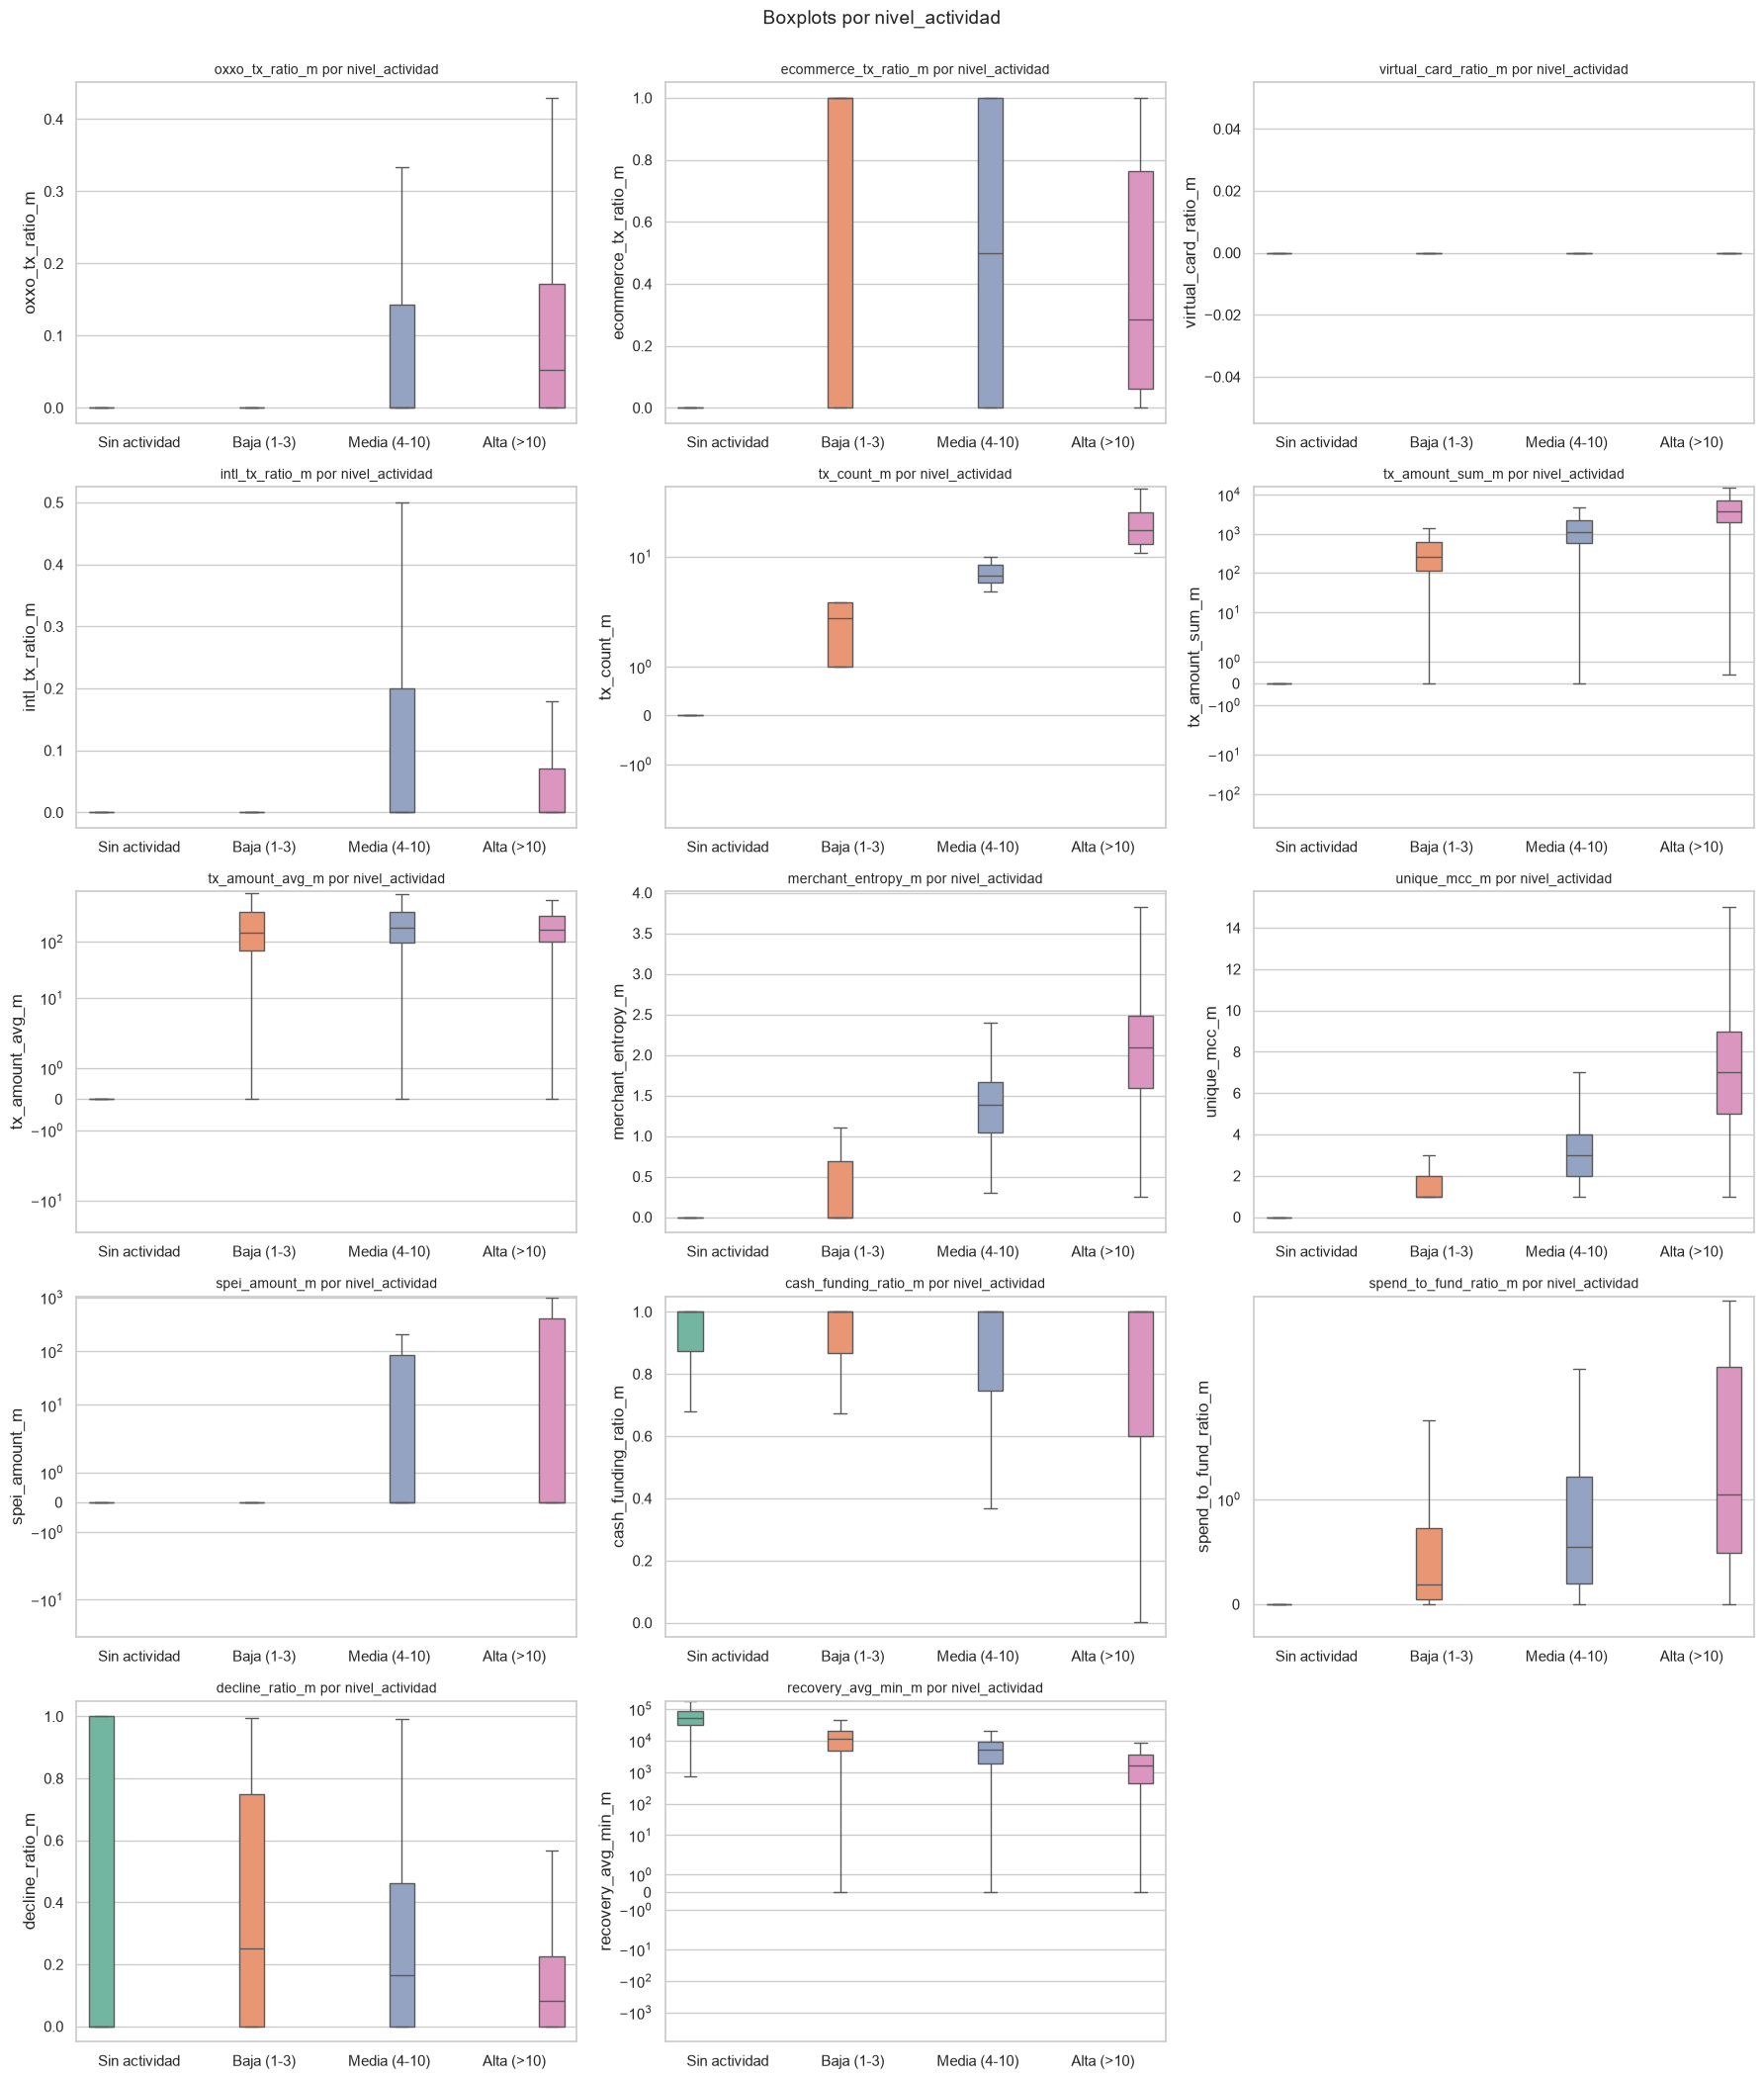

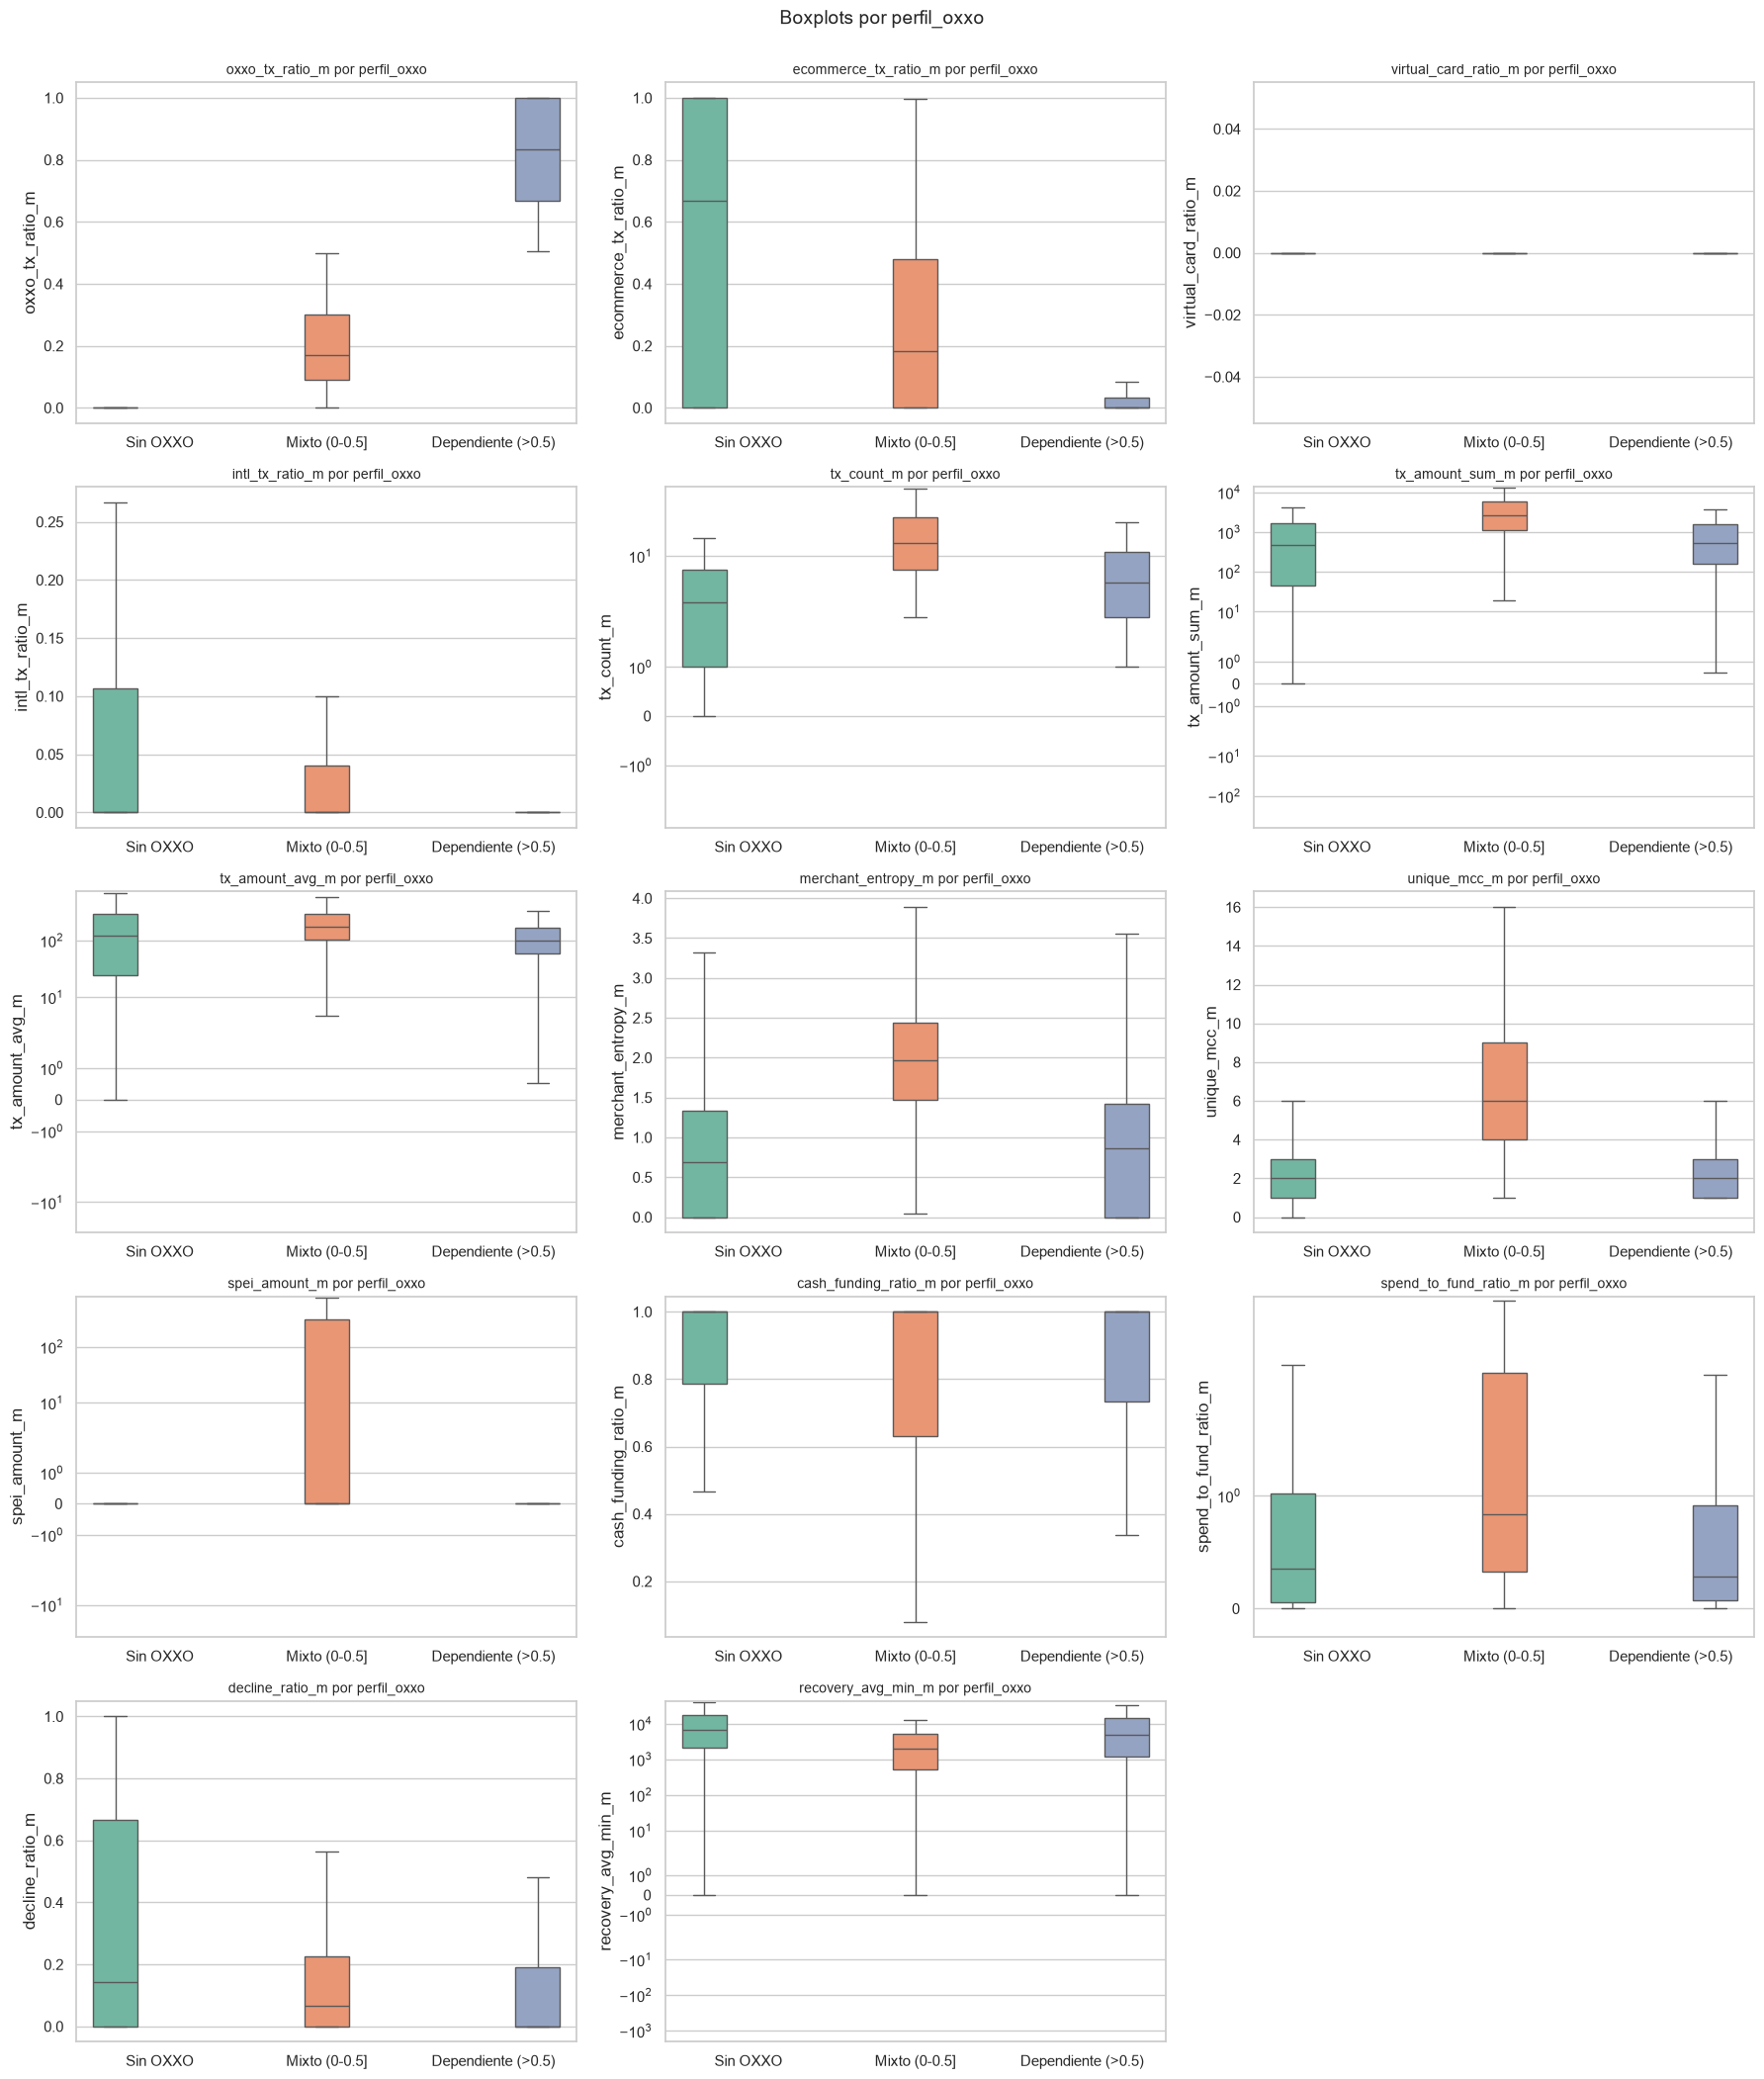

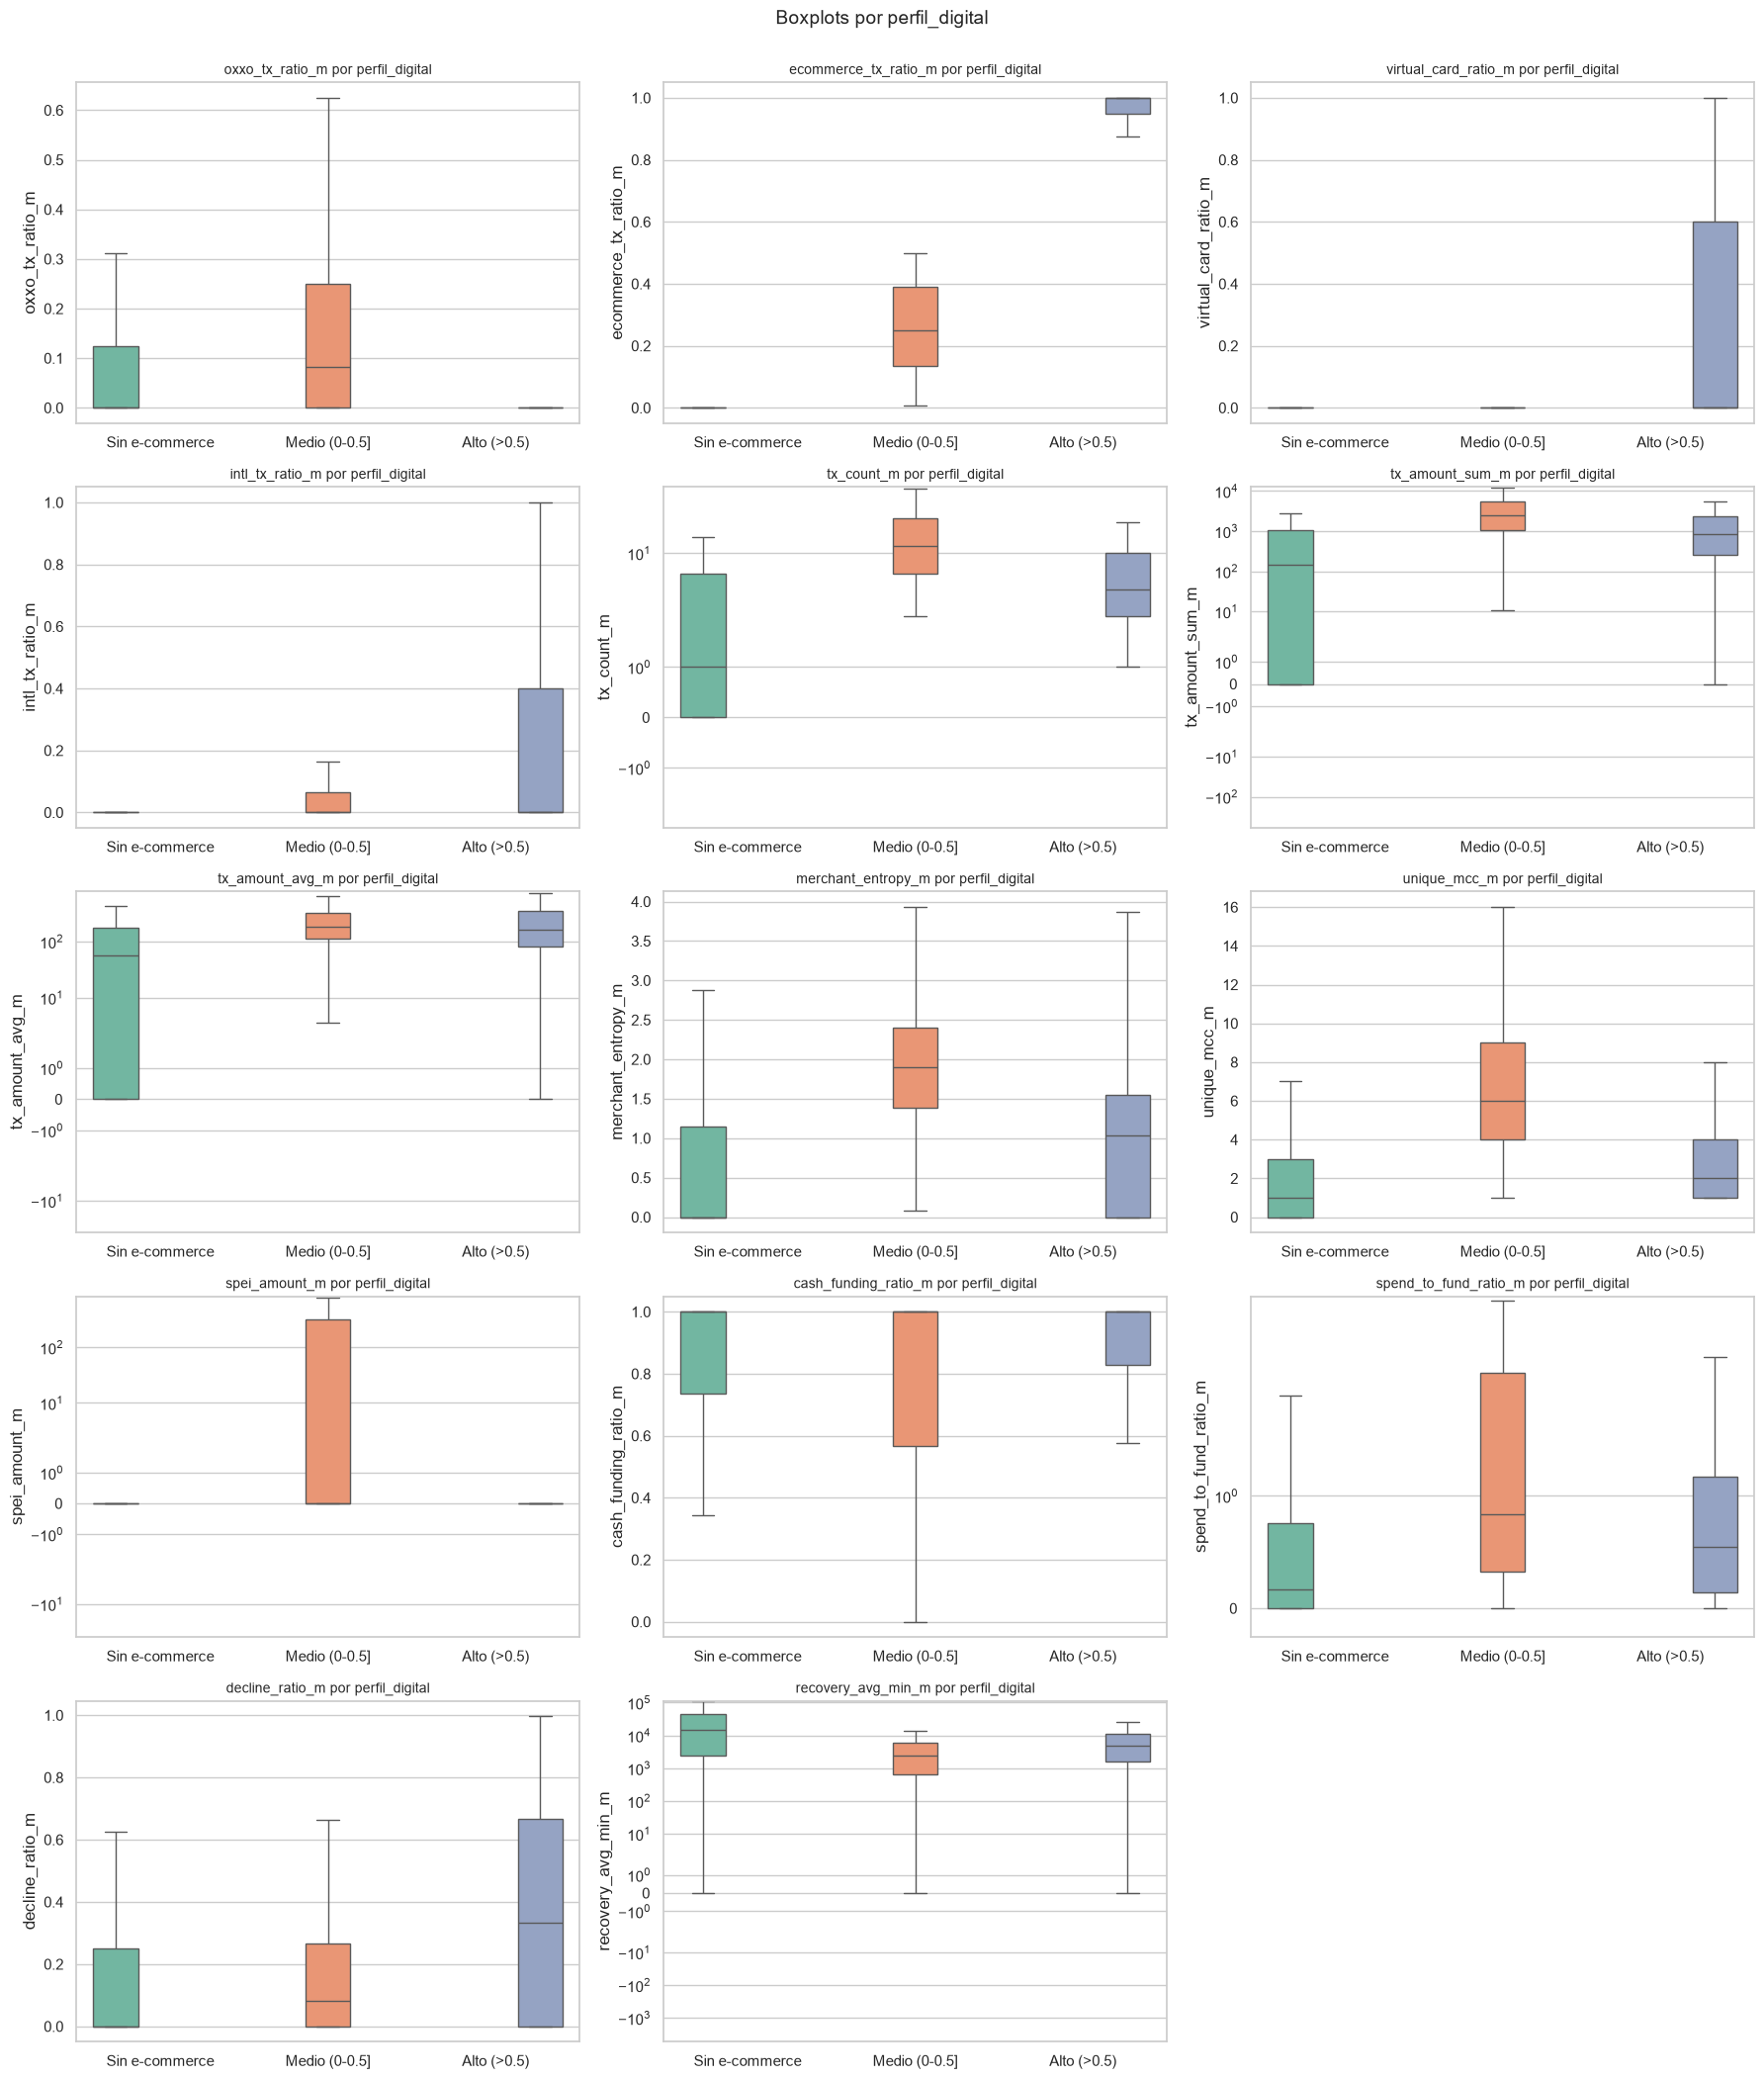

In [5]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = "data/g5_dataSample_v2_processed.csv"   

MUESTRA = 200_000                        

sns.set_theme(style="whitegrid")

df = pd.read_csv(data)


imputadas = {
    "oxxo_ratio_avg_prev3m": "oxxo_ratio_avg_prev3m_was_missing",
    "recovery_avg_min_m": "recovery_avg_min_m_was_missing",
    "cash_funding_ratio_m": "cash_funding_ratio_m_was_missing",       
    "spend_to_fund_ratio_m": "spend_to_fund_ratio_m_was_missing",     
}
for col, flag in imputadas.items():
    if flag in df.columns:                     
        df.loc[df[flag], col] = np.nan


for col in ["cash_funding_ratio_m", "spend_to_fund_ratio_m"]:
    if f"{col}_was_missing" not in df.columns and "is_zero_funding_m" in df.columns:
        df.loc[df["is_zero_funding_m"], col] = np.nan

# Variables categóricas

df["mes"] = pd.to_datetime(df["mes"]).dt.strftime("%Y-%m")

df["nivel_actividad"] = pd.cut(
    df["tx_count_m"], bins=[-1, 0, 3, 10, np.inf],
    labels=["Sin actividad", "Baja (1-3)", "Media (4-10)", "Alta (>10)"],
)
df["perfil_oxxo"] = pd.cut(
    df["oxxo_tx_ratio_m"], bins=[-0.001, 0, 0.5, 1.0],
    labels=["Sin OXXO", "Mixto (0-0.5]", "Dependiente (>0.5)"],
)
df["perfil_digital"] = pd.cut(
    df["ecommerce_tx_ratio_m"], bins=[-0.001, 0, 0.5, 1.0],
    labels=["Sin e-commerce", "Medio (0-0.5]", "Alto (>0.5)"],
)

categoricas = ["nivel_actividad", "perfil_oxxo", "perfil_digital"]

# Identificar las categorías de cada variable
print("=== Categorías por variable categórica ===")
for c in categoricas:
    print(f"{c}: {df[c].value_counts(dropna=False).sort_index().to_dict()}")


# Variables cuantitativas

cuantitativas = [
    "oxxo_tx_ratio_m", "ecommerce_tx_ratio_m", "virtual_card_ratio_m", "intl_tx_ratio_m",
    "tx_count_m", "tx_amount_sum_m", "tx_amount_avg_m", "merchant_entropy_m",
    "unique_mcc_m", "spei_amount_m", "cash_funding_ratio_m", "spend_to_fund_ratio_m",
    "decline_ratio_m", "recovery_avg_min_m",
]

escala_log = {"tx_count_m", "tx_amount_sum_m", "tx_amount_avg_m", "spei_amount_m",
              "spend_to_fund_ratio_m", "recovery_avg_min_m"}


datos = df.sample(MUESTRA, random_state=42) if MUESTRA and len(df) > MUESTRA else df


def boxplots_por_categoria(cat, datos, cuantitativas, ncols=3):
    """Un panel por variable cuantitativa, agrupado por las categorías de `cat`."""
    nrows = int(np.ceil(len(cuantitativas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    sub = datos.dropna(subset=[cat])
    orden = sorted(sub[cat].unique()) if sub[cat].dtype != "category" else list(sub[cat].cat.categories)
    for ax, num in zip(axes, cuantitativas):
        sns.boxplot(data=sub, x=cat, y=num, order=orden, ax=ax,
                    showfliers=False, palette="Set2", hue=cat, legend=False)
        if num in escala_log:
            ax.set_yscale("symlog")
        ax.set_title(f"{num} por {cat}", fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45 if cat == "mes" else 0)
    for ax in axes[len(cuantitativas):]:
        ax.axis("off")
    fig.suptitle(f"Boxplots por {cat}", fontsize=14, y=1.0)
    fig.tight_layout()
    plt.show()


for cat in categoricas:
    boxplots_por_categoria(cat, datos, cuantitativas)